# Transferring thermal annotations to RGB with OWL

The BAMBI drones record RGB and thermal simultaneously, but the two streams are
**not perfectly aligned**. A bounding box annotated on a thermal frame does not
sit on the animal in the corresponding RGB frame, so the thermal MOT labels
cannot be reused for RGB as they are.

The dataset already ships one solution for this: the patch-based
[BBox Corrections](https://github.com/HugoMarkoff/BAMBI_BBox_Corrections)
toolkit, which template-matches the thermal crop into a search window of the RGB
frame. This notebook demonstrates a **complementary, detector-based** approach:

> Find the animals directly in the RGB frame with
> [**OWL**](https://github.com/microsoft/MegaDetector-Overhead) (Overhead
> Wildlife Locator, Microsoft AI for Good), associate its points with the
> thermal box centres using the Hungarian algorithm, and re-centre each thermal
> box on the point it was matched to.

The two approaches fail in different ways: template matching needs the animal
to *look* similar across modalities, while OWL needs it to be *detectable* in
RGB and unambiguous among its neighbours.

Everything below uses `transfer_labels.py` from this repository.

**Contents**

1. [What the misalignment actually is](#1)
2. [Get the data](#2)
3. [What the download contains](#3)
4. [Detect animals in RGB with OWL](#4)
5. [The transfer, stage by stage](#5)
6. [Look at the result](#6)
7. [Evaluation](#7)
8. [Results on the full matched subset](#8)
9. [Limitations](#9)

<a id="1"></a>
## 1. What the misalignment actually is

Before building anything, it is worth measuring the problem. Over the
**247,382** boxes of the `matched` subset that carry both a thermal and an
accepted RGB annotation:

| quantity | value |
|---|---|
| `bb_width` / `bb_height` difference between the views | **exactly 0**, for every box |
| centre shift, median magnitude | 10.3 px |
| centre shift, p90 / p99 / max | 34 / 54 / 116 px |
| per-flight mean shift | −37 … +20 px in x, −20 … +27 px in y |
| shift variation *within* a flight (sd) | up to 22 px |

Two consequences shape the whole method:

* The boxes never change size, so **transfer is a pure 2-D translation
  problem**: only `(dx, dy)` has to be estimated for each box.
* The shift varies between flights *and drifts within* a flight, so a single
  global offset per video is not enough. That rules out calibrating once and
  applying everywhere.

Frames are 1024×1024 in both modalities.

In [1]:
%matplotlib inline

import subprocess
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# transfer_labels.py lives in the repository root, next to this notebook.
sys.path.insert(0, str(Path.cwd()))
import transfer_labels as tl

FLIGHT = "119"          # single animal, large (32 px) and drifting shift
FLIGHT_MULTI = "163"    # 16 tracks, several animals per frame

DATA = Path("./bambi_downloads")
WORK = Path("./owl_transfer_demo")
WORK.mkdir(exist_ok=True)
print("transfer_labels loaded from", tl.__file__)

transfer_labels loaded from /scratch/bambi/owl_transfer/nbrun/transfer_labels.py


<a id="2"></a>
## 2. Get the data

The **matched** release is used here because it is the only one that ships
*both* the thermal MOT labels and the human-accepted RGB MOT labels, and the
latter serves as the reference to score against.

Flight 119 is a good demonstration case: one animal at a time, a large mean
shift of 32 px, and that shift drifts noticeably over the flight. Flight 163 is
added later for the multi-animal questions.

In [2]:
# One directory per flight: the archives unpack FLAT (rgb/, thermal/, labels/,
# manifest.json at the top level), so downloading two flights into the same
# folder would merge their frames into one rgb/ directory.
for f in (FLIGHT, FLIGHT_MULTI):
    dest = DATA / f
    if (dest / "labels").is_dir():
        print(f"flight {f}: already present in {dest}")
        continue
    r = subprocess.run(
        [sys.executable, "download_from_zenodo.py", "--version", "matched",
         "-f", f, "--unzip", "-o", str(dest)],
        capture_output=True, text=True)
    # The downloader prints a progress line every 8 MB; drop those so the
    # rendered notebook does not carry 130 of them per flight.
    print("\n".join(l for l in r.stdout.splitlines() if " MB (" not in l).strip())
    if r.returncode:
        print(r.stderr[-2000:])

flight 119: already present in bambi_downloads/119
flight 163: already present in bambi_downloads/163


<a id="3"></a>
## 3. What the download contains

Unlike the base release, the **matched** archives ship frames that are *already
extracted*, so `frame_extraction.py` is not needed here. Each `flight_<N>.zip`
unpacks to:

```
rgb/<frame>.jpg                     extracted RGB frames
thermal/<frame>.jpg                 extracted thermal frames, same frame index
labels/<flight>_rgb_mot.txt         accepted RGB boxes
labels/<flight>_thermal_mot.txt     thermal boxes
labels/<flight>_labels.json         per-track gender, occlusion, provenance
manifest.json                       frame counts and label provenance
```

Note that this is the *top level* of the archive: there is no `flight_<N>/`
wrapper, which is why the previous cell gives each flight its own destination
directory. Frame file names are the zero-padded source-video frame index and
are shared across modalities, so `rgb/000010.jpg` and `thermal/000010.jpg` are
the pair.

**One detail that matters for this notebook.** Frames were extracted at a fixed
stride, but the `frame` column of the MOT files is a full-rate video index, so
many annotated rows have **no** corresponding image. OWL can only score frames
that exist as images; boxes on the frames in between get their shift from the
consensus curve instead. That accounts for a large part of the `consensus`
share in the source breakdown later.

In [3]:
def find_one(pattern, flight=None):
    root = DATA / flight if flight else DATA
    hits = sorted(root.rglob(pattern))
    if not hits:
        raise FileNotFoundError(f"no match for {pattern} under {root}")
    return hits[0]

thermal_mot = find_one(f"{FLIGHT}_thermal_mot.txt", FLIGHT)
rgb_mot     = find_one(f"{FLIGHT}_rgb_mot.txt", FLIGHT)
rgb_dir     = thermal_mot.parent.parent / "rgb"

images = sorted(rgb_dir.glob("*.jpg"))
print("thermal labels :", thermal_mot)
print("accepted RGB   :", rgb_mot)
print("RGB frames     :", len(images), "in", rgb_dir)
print("frame indices  :", ", ".join(p.stem for p in images[:5]), "...")

thermal labels : bambi_downloads/119/labels/119_thermal_mot.txt
accepted RGB   : bambi_downloads/119/labels/119_rgb_mot.txt
RGB frames     : 1215 in bambi_downloads/119/rgb
frame indices  : 000000, 000010, 000020, 000030, 000040 ...


<a id="4"></a>
## 4. Detect animals in RGB with OWL

OWL is a heatmap **point** detector for aerial wildlife imagery: it returns a
point per animal, not a box. That suits the task at hand: the box size already
comes from the thermal annotation, only the position is missing.

Three checkpoints are released. On BAMBI RGB, zero-shot, they rank clearly:

| model | backbone | zero-shot f1 on BAMBI RGB | speed (A100, 1024² frame) |
|---|---|---|---|
| OWL-C | DLA-34 | 0.354 | ~0.14 s |
| OWL-T | Swin | 0.240 | n/a |
| **OWL-D** | **ViT-H/16** | **0.513** | **~1.3 s** |

OWL-D is ~10× slower but transfers far better (p90 error 8.6 px vs 18.7 px for
OWL-C), so it is worth the GPU time. Everything below uses OWL-D.

### Running it

```bash
git clone https://github.com/microsoft/MegaDetector-Overhead.git
cd MegaDetector-Overhead
uv sync --no-default-groups --group gpu      # CUDA 12.1 / torch 2.5.1
# download OWL-D.pth from the repository's release page into ./ckpt/
```

OWL is driven by Hydra. It needs an input CSV listing the images to score, with
a sentinel annotation row per image (this is what `tools/infer.py` does for
unannotated input):

```bash
python tools/test.py test=owld_caribou_demo \
    ++test.device_name=cuda \
    ++test.model.pth_file=./ckpt/OWL-D.pth \
    ++test.dataset.root_dir=/abs/path/to/rgb_frames \
    ++test.dataset.csv_file=/abs/path/to/owl_input.csv \
    ++hydra.run.dir=/abs/path/to/owl_out
```

### Two common pitfalls

1. **The output is in heatmap coordinates, not image pixels.** The shipped
   configs run the stitcher with `down_ratio: 2` and `up: False`, so a point in
   a 1024×1024 frame comes back in the range `0..511`. Multiply by 2. Point
   localisation is therefore quantised to 2 px.
2. **`FolderDataset` ignores directories in the CSV and adds strays.** It
   reduces every path in the `images` column to its basename, *and* appends
   every image it finds in `root_dir` that the CSV does not mention. Its
   `root_dir` must be a flat folder containing exactly the frames to be
   scored, nothing more and nothing less.

Conveniently, the matched release already provides a flat `rgb/` folder holding
exactly the frames to be scored, so it can serve as `root_dir` unchanged.

The two cells below build the input CSV and convert the result. Both are safe
to run without a GPU; only the `tools/test.py` call above requires one.

In [4]:
# --- build the OWL input CSV -------------------------------------------------
# Sentinel rows: OWL keys on annotation rows, so every image needs one even
# though no ground truth exists for it.
import csv

owl_input = WORK / f"owl_input_{FLIGHT}.csv"
with open(owl_input, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["images", "x", "y", "labels"])
    for p in images:
        w.writerow([p.name, 0, 0, 1])
print(f"{len(images)} frames -> {owl_input}")
print(f"use --> ++test.dataset.root_dir={rgb_dir.resolve()}")

1215 frames -> owl_transfer_demo/owl_input_119.csv
use --> ++test.dataset.root_dir=/scratch/bambi/owl_transfer/nbrun/bambi_downloads/119/rgb


In [5]:
# --- convert OWL's detections.csv into the compact format --------------------
# Run this AFTER tools/test.py. detections.csv columns:
#   images, labels, dscores, x, y, count_1, species
# Frames where nothing was found appear once with empty x/y - keep them, since
# "looked and found nothing" is different from "never processed".
SCALE = 2.0     # heatmap -> image pixels (down_ratio=2, up=False)

def convert_owl_output(detections_csv, out_csv):
    rows = []
    with open(detections_csv) as fh:
        for r in csv.DictReader(fh):
            frame = int(Path(r["images"]).stem.rpartition("_")[2])
            if not r["x"] or r["x"] == "nan":
                continue
            rows.append((frame, round(float(r["x"]) * SCALE, 1),
                         round(float(r["y"]) * SCALE, 1),
                         round(float(r["dscores"]), 4)))
    rows.sort()
    with open(out_csv, "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["frame", "x", "y", "score"])
        w.writerows(rows)
    return len(rows)

# n = convert_owl_output(Path("owl_out/detections.csv"),
#                        WORK / f"owl_detections_flight{FLIGHT}.csv")

To keep this notebook runnable **without a GPU**, precomputed OWL-D detections
for both demo flights ship with the repository under
`examples/owl_transfer/`. They are already in image pixels.

In [6]:
DETS = Path("examples/owl_transfer")
det_file = DETS / f"owl_detections_flight{FLIGHT}.csv"

detections = tl.read_detections(det_file)
n_points = sum(len(v) for v in detections.values())
print(f"{len(detections)} frames scored, {n_points} detections "
      f"({n_points / len(detections):.2f} per frame)")

734 frames scored, 838 detections (1.14 per frame)


<a id="5"></a>
## 5. The transfer, stage by stage

`transfer_labels.py` runs four stages. They are called one at a time below so
that the contribution of each is visible.

### Stage 1: Hungarian matching

Per frame, thermal box centres are assigned to OWL points by rectangular
Hungarian assignment on Euclidean distance. A hard gate (60 px, just above the
p99 of the observed shift) stops an isolated detection from capturing a box on
the far side of the image. Each accepted assignment gives a raw shift,
`point − centre`.

In [7]:
rows = tl.read_mot(thermal_mot)
print(f"{len(rows)} thermal boxes, "
      f"{len({r['track_id'] for r in rows})} tracks, "
      f"frames {min(r['frame'] for r in rows)}..{max(r['frame'] for r in rows)}")

raw = tl.match_frames(rows, detections, gate=60.0)
print(f"stage 1: {len(raw)} of {len(rows)} boxes matched to a point "
      f"({100 * len(raw) / len(rows):.1f}%)")

d = np.array([[v[0], v[1]] for v in raw.values()])
print(f"raw shift: mean ({d[:, 0].mean():+.1f}, {d[:, 1].mean():+.1f}) px, "
      f"sd ({d[:, 0].std():.1f}, {d[:, 1].std():.1f})")

822 thermal boxes, 4 tracks, frames 0..3968
stage 1: 733 of 822 boxes matched to a point (89.2%)
raw shift: mean (-30.0, +5.9) px, sd (17.4, 14.1)


### Stage 2: the consensus curve

Misalignment is largely a **whole-frame** effect that drifts slowly, so the
median shift of a frame is a far steadier quantity than any single detection.
Taking a rolling median of those per-frame medians over time gives a curve that
is defined even on frames where a particular animal was never detected, and
that is what fills the gaps.

The plot makes the central claim of section 1 concrete: the shift is neither
zero nor constant.

consensus built from 733 frames


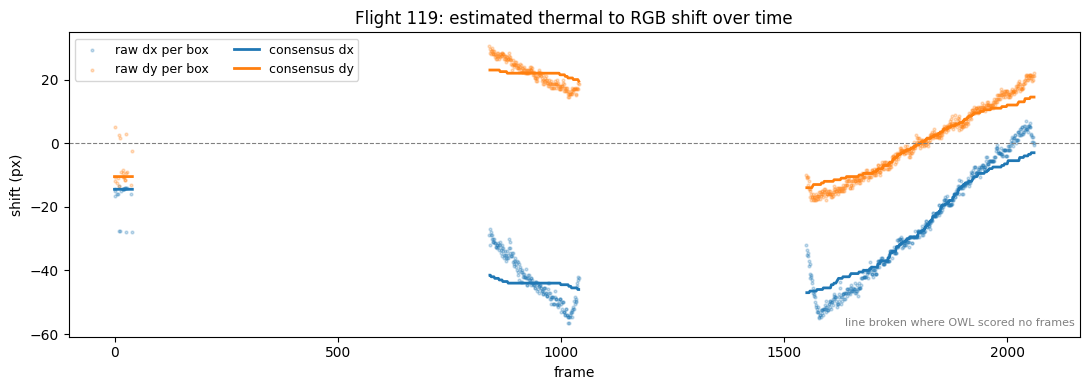

In [8]:
consensus = tl.ConsensusCurve(raw, half_window=150.0)
print(f"consensus built from {len(consensus)} frames")

frames_sorted = np.array(sorted(detections))
curve = np.array([consensus.at(int(f)) for f in frames_sorted])

# Break the line across stretches OWL never scored, so the plot does not imply
# a known shift where there is no evidence for one.
curve = curve.astype(float)
curve[np.diff(frames_sorted, prepend=frames_sorted[0]) > 50] = np.nan

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter([k[0] for k in raw], [v[0] for v in raw.values()],
           s=4, alpha=.25, color="tab:blue", label="raw dx per box")
ax.scatter([k[0] for k in raw], [v[1] for v in raw.values()],
           s=4, alpha=.25, color="tab:orange", label="raw dy per box")
ax.plot(frames_sorted, curve[:, 0], color="tab:blue", lw=2, label="consensus dx")
ax.plot(frames_sorted, curve[:, 1], color="tab:orange", lw=2, label="consensus dy")
ax.axhline(0, color="grey", lw=.8, ls="--")
ax.set_xlabel("frame"); ax.set_ylabel("shift (px)")
ax.set_title(f"Flight {FLIGHT}: estimated thermal to RGB shift over time")
ax.text(0.995, 0.03, "line broken where OWL scored no frames", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color="grey")
ax.legend(ncol=2, fontsize=9); fig.tight_layout()

### Stage 3: re-match with the consensus as a prior

In a frame holding several animals, the first pass can hand a box its
*neighbour's* point, especially when the shift is large, because then the
nearest detection to a thermal box may well belong to the animal next to it.
Re-running the assignment with distances measured from the **consensus-shifted**
centre removes most of that, and lets the gate be much tighter (45 px).

In [9]:
refined = tl.match_frames(rows, detections, gate=45.0, prior=consensus)
changed = sum(1 for k, v in refined.items()
              if k not in raw or abs(v[0] - raw[k][0]) > 1e-6)
print(f"stage 3: {len(refined)} matched, {changed} assignments new or changed")
consensus = tl.ConsensusCurve(refined, half_window=150.0)

stage 3: 733 matched, 2 assignments new or changed


### Stage 4: smooth each track over time

The true shift drifts slowly; the detector's per-frame localisation noise does
not. A ±15-frame rolling median per track separates the two. On densely
annotated flights this is worth about 5% of the remaining error.

Boxes that still have no match take the consensus. If a flight yielded no
matches at all, its boxes are left untouched rather than moved by a guess.

In [10]:
shifts = tl.estimate_shifts(rows, detections,
                            gate=60.0, gate2=45.0,
                            cons_window=150.0, smooth=15.0)
moved = tl.apply_shifts(rows, shifts)

from collections import Counter
print("shift source:", Counter(r["source"] for r in moved).most_common())

out_mot = WORK / f"{FLIGHT}_rgb_mot.txt"
tl.write_mot(out_mot, moved)
tl.write_provenance(WORK / f"{FLIGHT}_rgb_mot_provenance.csv", moved)
print("written:", out_mot)
!head -3 {out_mot}

shift source: [('smoothed', 733), ('consensus', 89)]
written: owl_transfer_demo/119_rgb_mot.txt





<a id="6"></a>
## 6. Look at the result

Nothing substitutes for looking at the pixels. Red is the thermal box where it
would land on RGB if used unchanged, green is the transferred box, blue is the
human-accepted reference, and yellow circles are OWL's points.

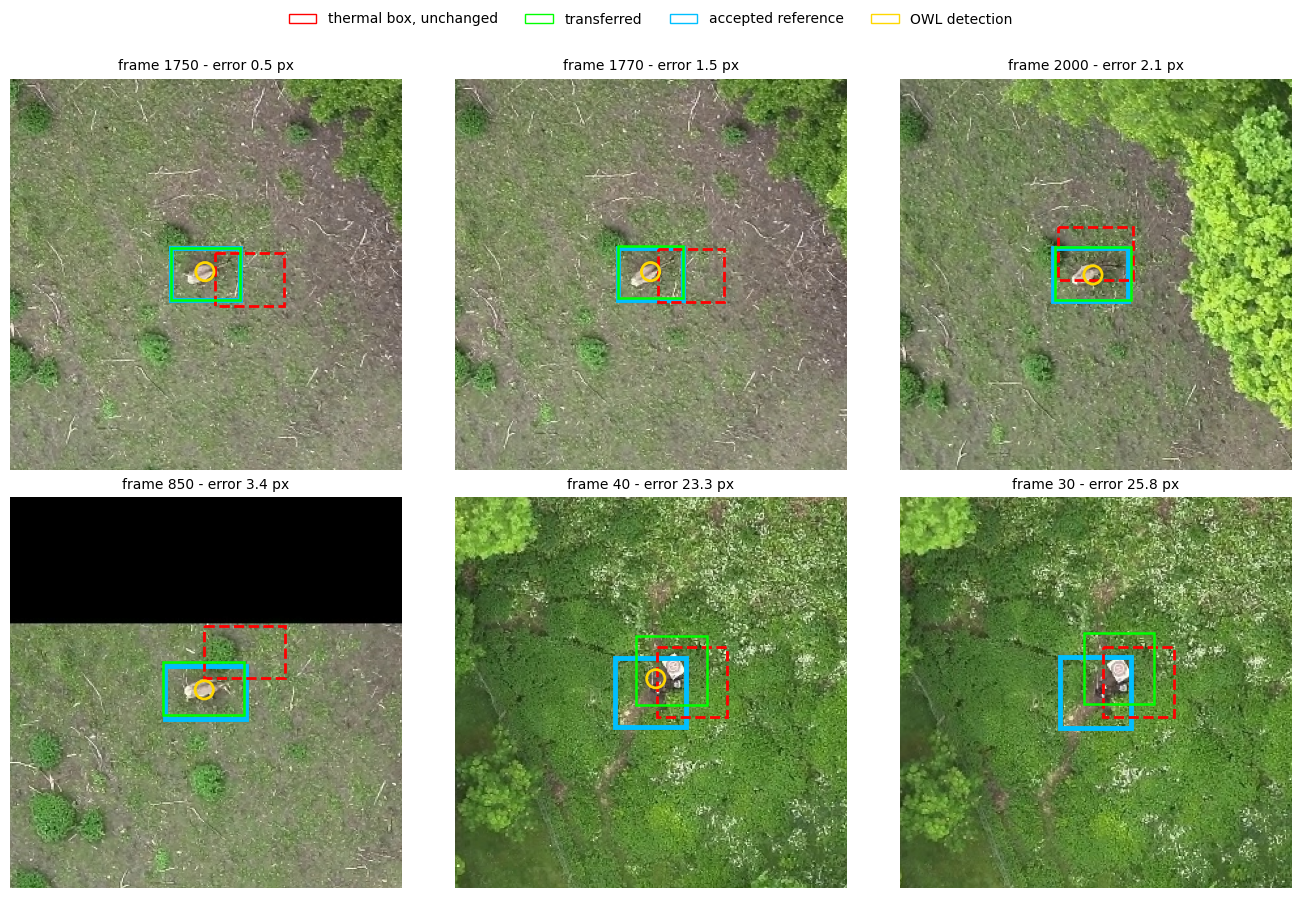

In [11]:
import matplotlib.patches as mpatches
from matplotlib.image import imread

ref_rows = tl.read_mot(rgb_mot)
ref_by_key = {(r["frame"], r["track_id"]): r for r in ref_rows}
thermal_by_key = {(r["frame"], r["track_id"]): r for r in rows}
by_index = {int(p.stem): p for p in images}

def centre(b):
    return b["left"] + b["width"] / 2, b["top"] + b["height"] / 2

# Score every box that can be both shown and checked, then sample across the
# error range: a panel of only the good cases would not be worth much.
scored = []
for r in moved:
    key = (r["frame"], r["track_id"])
    if r["frame"] not in by_index or key not in ref_by_key:
        continue
    (px, py), (gx, gy) = centre(r), centre(ref_by_key[key])
    scored.append((float(np.hypot(px - gx, py - gy)), key))
scored.sort()
picks = [scored[int(q * (len(scored) - 1))]
         for q in (0.02, 0.25, 0.50, 0.75, 0.95, 1.00)]

def show(err, key, ax, pad=150):
    frame_no, _track = key
    img = imread(by_index[frame_no])
    ax.imshow(img)
    # Reference first and thick, transferred on top and thin: at ~3 px error
    # the two boxes almost coincide, and a same-weight green would simply be
    # hidden underneath the blue.
    for colour, lw, style, b in (
            ("deepskyblue", 3.5, "-", ref_by_key.get(key)),
            ("red", 2.0, "--", thermal_by_key.get(key)),
            ("lime", 1.8, "-", next(r for r in moved
                                    if (r["frame"], r["track_id"]) == key))):
        if b is None:
            continue
        ax.add_patch(mpatches.Rectangle(
            (b["left"], b["top"]), b["width"], b["height"], fill=False,
            edgecolor=colour, lw=lw, linestyle=style))
    for px, py, _s in detections.get(frame_no, []):
        ax.add_patch(mpatches.Circle((px, py), 7, fill=False,
                                     edgecolor="gold", lw=2))
    cx, cy = centre(ref_by_key[key])
    h, w = img.shape[:2]
    cx = min(max(cx, pad), w - pad); cy = min(max(cy, pad), h - pad)
    ax.set_xlim(cx - pad, cx + pad); ax.set_ylim(cy + pad, cy - pad)
    ax.set_title(f"frame {frame_no} - error {err:.1f} px", fontsize=10)
    ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9))
for ax, (err, key) in zip(axes.ravel(), picks):
    show(err, key, ax)
handles = [mpatches.Patch(edgecolor=c, facecolor="none", label=l)
           for c, l in (("red", "thermal box, unchanged"),
                        ("lime", "transferred"),
                        ("deepskyblue", "accepted reference"),
                        ("gold", "OWL detection"))]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.95])

Top row: the transferred box sits on the reference closely enough that the
green outline disappears inside the blue one, while the dashed red thermal box
is clearly off the animal, which is the whole point.

The bottom-right two panels are the 95th and 100th percentile of this flight's
error, and they are worth a second look: OWL's point is on the animal, the
green box is centred on it, and it is the *blue reference* that sits low and to
the left. At the top of the error range the disagreement is not always the
transfer being wrong. That is a caution about reading these numbers as
accuracy rather than as agreement (see section 7), not a claim that the
reference is generally worse.

<a id="7"></a>
## 7. Evaluation

The reference is the accepted RGB MOT of the `matched` subset. Two things to
keep in mind when reading any number below:

* Those labels are the **template matcher's output after human acceptance**, so
  the quantity being measured is *agreement with the manually accepted
  corrections*, not independent accuracy.
* Predicted and reference boxes always share width and height, so centre error
  and IoU are two views of the same quantity. IoU is reported anyway because it
  is what a downstream user of the labels actually feels.

The comparison is made **per track**: a predicted box is scored against the
reference box with the *same* `track_id`, never against whichever box happens
to be nearest. A label that lands on the neighbouring animal therefore counts
as a large error, not as a hit.

In [12]:
metrics = tl.evaluate(moved, ref_rows, rows)
print(tl.format_report(f"flight {FLIGHT}", metrics))

flight 119: 753 boxes with an accepted RGB reference
                            mean  median     p90     IoU   IoU>.5  IoU>.75
  unchanged (thermal)      36.29   39.46   54.77   0.187     0.0%     0.0%
  transferred               3.49    2.24    4.27   0.852    94.3%    92.3%
  closer to the reference than leaving it alone: 100.0%  (worse: 0.0%)
  shift source: smoothed 733, consensus 89


Flight 119 has only one animal on screen at a time, so it cannot exercise the
identity question. Flight 163, with 16 tracks and several animals per frame, can.

In [13]:
thermal_mot_m = find_one(f"{FLIGHT_MULTI}_thermal_mot.txt", FLIGHT_MULTI)
rgb_mot_m     = find_one(f"{FLIGHT_MULTI}_rgb_mot.txt", FLIGHT_MULTI)

rows_m = tl.read_mot(thermal_mot_m)
dets_m = tl.read_detections(DETS / f"owl_detections_flight{FLIGHT_MULTI}.csv")
moved_m = tl.apply_shifts(rows_m, tl.estimate_shifts(rows_m, dets_m))

print(tl.format_report(f"flight {FLIGHT_MULTI}",
                       tl.evaluate(moved_m, tl.read_mot(rgb_mot_m), rows_m)))

flight 163: 1232 boxes with an accepted RGB reference
                            mean  median     p90     IoU   IoU>.5  IoU>.75
  unchanged (thermal)      14.40   14.14   18.00   0.491    46.2%     0.0%
  transferred               3.22    3.02    5.52   0.847   100.0%    87.3%
  closer to the reference than leaving it alone: 100.0%  (worse: 0.0%)
  on the right animal, in multi-animal frames : 100.00%  (1071 boxes)
  shift source: smoothed 1340, consensus 84


The `on the right animal` line is the identity check: for every frame holding
at least two annotated animals, is the nearest reference box to a prediction
its *own*? It only sees animals that were annotated, so it is a lower bound;
see the limitations below.

<a id="8"></a>
## 8. Results on the full matched subset

The numbers below come from running OWL-D over **every annotated frame of the
`matched` subset that has an RGB image**: 94,935 frames, 444,057 detections,
**252,857 thermal boxes transferred**, of which 234,264 have an accepted RGB
reference to score against. 84.6% of boxes were matched to an OWL point; the
rest took the consensus curve, and 91 (0.04%) were left untouched.

Settings: `--gate 60 --gate2 45 --cons-window 150 --smooth 15`.

### Headline

| | mean err | median | p90 | IoU | IoU>0.5 | IoU>0.75 |
|---|---|---|---|---|---|---|
| unchanged (thermal box as-is) | 14.97 px | 11.40 | 35.06 | 0.533 | 51.5% | 31.8% |
| oracle: per-flight median shift | 8.63 | 4.12 | 26.17 | 0.709 | 77.9% | 58.2% |
| oracle: per-frame median shift | 3.24 | 1.41 | 8.14 | 0.872 | 94.5% | 84.5% |
| **OWL transfer** | **4.31** | **2.92** | **7.28** | **0.818** | **95.9%** | **80.9%** |

The two oracle rows fit one shift per flight / per frame **using the reference**,
so they bound what any global-registration approach could achieve.

### Interpreting the per-frame oracle

In a frame with a single annotated animal, the median of one true shift *is*
that shift, so the oracle scores exactly 0.00 px there: it is reading the
answer, not estimating. That is 19.8% of boxes and it flatters the row above.
Restricted to frames where it actually has something to estimate:

| frames with 2+ animals (187,785 boxes, 80.2%) | mean | median | p90 | IoU | IoU>0.5 | IoU>0.75 |
|---|---|---|---|---|---|---|
| unchanged | 13.19 | 9.22 | 28.23 | 0.566 | 56.2% | 35.6% |
| oracle: per-frame median shift | 4.04 | 2.06 | 10.00 | 0.840 | 93.2% | 80.7% |
| OWL transfer | 4.06 | 2.92 | **6.80** | 0.824 | **96.7%** | **82.1%** |

A dead heat on mean error against a method allowed to see the answer, and ahead
of it in the tail. The oracle keeps a better mean IoU because it nails a subset
exactly; the detector-based method has the better tail because it estimates a
shift **per object** rather than inheriting one frame-wide value.

### By provenance of the shift

| source | n | mean err | p90 | IoU | IoU>0.5 | unchanged, same rows |
|---|---|---|---|---|---|---|
| matched to an OWL point | 207,314 | 3.59 | 6.18 | 0.839 | 98.1% | 15.07 |
| consensus curve | 26,859 | 9.80 | 25.87 | 0.653 | 79.2% | 14.16 |
| left untouched | 91 | 18.92 | 18.97 | 0.193 | 0.0% | 18.92 |

### Error versus the size of the correction

| reference shift | 0–2 px | 2–5 | 5–10 | 10–20 | 20–40 | 40+ |
|---|---|---|---|---|---|---|
| unchanged | 0.98 | 3.17 | 7.04 | 15.37 | 27.18 | 47.92 |
| OWL transfer | 5.06 | 3.32 | 3.21 | 4.55 | 4.73 | 6.40 |

Residual error is nearly flat in the size of the correction: the method does
not degrade where it is needed most. Its one loss is the 0–2 px bucket (10% of
boxes), where the thermal box was already correct and the detector moves it by
its own noise.

### Did it land on the right animal?

Over the 187,785 boxes in frames with at least two annotated animals:

| | on the right animal | on the wrong animal |
|---|---|---|
| thermal box, unchanged | 186,489 (99.31%) | 1,296 (0.69%) |
| OWL transfer | **187,163 (99.67%)** | **622 (0.33%)** |

Transfer roughly **halves** identity confusion rather than introducing it, and
there is exactly one true pairwise swap (A→B and B→A in the same frame) in all
234,264 boxes.

### Ablation

| variant | mean err | p90 | IoU>0.5 |
|---|---|---|---|
| single-pass Hungarian, 60 px gate | 4.94 | 8.08 | 94.6% |
| + consensus prior, second pass at 45 px | 4.57 | 7.65 | 95.6% |
| + per-track smoothing (±15 frames) | **4.31** | **7.28** | **95.9%** |

### Coverage

18,593 of the 252,857 transferred boxes (7.4%) have **no** accepted RGB
counterpart in `matched`, because template matching never produced one for them. They
are the coverage this approach adds, and they are unscoreable here for the same
reason.

<a id="9"></a>
## 9. Limitations

**Animals without a box on the frame can steal the assignment.** This is the
worst failure and it is systematic, not random.

BAMBI is annotated on key frames, with the boxes in between obtained by
interpolation (see `mot_interpolation.py` and the `is_propagated` column). A
given frame therefore often carries boxes for some of the animals in view and
not for the others, either because the missing tracks were keyed over a
different stretch of the flight or because their interpolated boxes are not
present in the label file being used. The animals are annotated; their box on
*that* frame is not.

**Flight 241 of the matched release** is a clean example. Its thermal label
file holds four tracks, each covering a disjoint stretch:

| track | frames | boxes |
|---|---|---|
| 1518 | 11370-11440 | 71 |
| 1544 | 11500-11560 | 61 |
| 1575 | 11750-11850 | 101 |
| 1612 | 11940-11980 | 41 |

Every one of its 274 frames carries **exactly one** box. Over frames
11940-11980, where only track 1612 is labelled, OWL detects **four to six**
animals per frame. So the assignment has one box and up to six candidate
points, and with a true shift of (-37.6, +21.3) px the nearest point to that
box belongs to a different animal. The pipeline then agrees with itself: the
consensus is built from those same wrong matches, so the second pass
re-confirms them, and the result is a shift of (+54.0, +14.6) px with a
standard deviation of 1.1 px. Confidently wrong, at 91.9 px mean error against
43.2 px for leaving the boxes alone.

No internal consistency check catches this, because every one of them is
satisfied. Breaking it needs a signal independent of OWL: a coarse global
thermal-to-RGB registration, or the template matcher, used as a shift prior
*before* matching. Interpolating the labels first (`mot_interpolation.py`) also
helps wherever the missing boxes are in-between frames of a track that is keyed
on both sides, since it gives the assignment a box to compete for. Neither
helps where a track is simply not annotated over that stretch, as in flight 241.

It is 0.06% of boxes, but it is the case to guard against before using the
output unreviewed. The `_provenance.csv` sidecar exists for that triage.

**The identity check is a lower bound.** It only looks at frames carrying two
or more boxes, so it is structurally blind to exactly the case above, where the
frame carries one.

**A detector floor.** Where OWL does not fire (dense canopy, very small or
occluded animals), the box falls back to the consensus curve, which is a
whole-frame estimate and averages 9.8 px rather than 3.6 px.

**The reference is not independent.** It is the template matcher's output after
human acceptance, so agreement with it is what these numbers express.

## See also

* [BAMBI BBox Corrections](https://github.com/HugoMarkoff/BAMBI_BBox_Corrections): the patch-based template-matching alternative
* [MegaDetector-Overhead](https://github.com/microsoft/MegaDetector-Overhead): OWL models and inference code